In [ ]:
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules, fpgrowth
import networkx as nx

items = [
    "milk", "bread", "eggs", "butter", "cheese",
    "yogurt", "chocolate", "coffee", "tea", "sugar",
    "apples", "bananas", "oranges", "grapes", "water",
    "pasta", "rice", "chicken", "beef", "fish"
]

N_TRANSACTIONS = 3000

def generate_transaction():
    size = random.randint(1, 7)
    return random.sample(items, size)

transactions = [generate_transaction() for _ in range(N_TRANSACTIONS)]
print("Сгенерировано транзакций:", len(transactions))

# Создаем таблицу как grocery.csv (товары по столбцам)
max_len = max(len(t) for t in transactions)
data_rows = [t + [None] * (max_len - len(t)) for t in transactions]
all_data = pd.DataFrame(data_rows)

print("\nПример данных:")
print(all_data.head())

Сгенерировано транзакций: 3000

Пример данных:
        0        1          2          3      4     5       6
0   bread    sugar      pasta       beef   None  None    None
1  yogurt   coffee    bananas  chocolate  sugar  eggs  apples
2   sugar     None       None       None   None  None    None
3    rice  oranges       None       None   None  None    None
4    eggs  oranges  chocolate       None   None  None    None


Преобразование транзакций в таблицу

Транзакции преобразуются в DataFrame: каждая транзакция — строка, товары — столбцы.  
Если в транзакции меньше элементов, чем столбцов, недостающие значения заполняются `None`.


In [ ]:

transaction_lengths = all_data.notnull().sum(axis=1)
print('\nСредняя длина транзакции:', transaction_lengths.mean())
print('Максимальная длина транзакции:', transaction_lengths.max())


Средняя длина транзакции: 3.9916666666666667
Максимальная длина транзакции: 7


Подготовка данных для FPGrowth

Удаляем `None` и преобразуем данные в формат, подходящий для алгоритмов `mlxtend`.  
TransactionEncoder создаёт бинарную таблицу: строки — транзакции, столбцы — товары, значения 0/1.


In [ ]:

np_data = all_data.to_numpy()
np_data = [[elem for elem in row if isinstance(elem, str)] for row in np_data]

te = TransactionEncoder()
te_ary = te.fit(np_data).transform(np_data)
data = pd.DataFrame(te_ary, columns=te.columns_)

In [4]:
Автоподбор параметров min_support и min_confidence

Перебираем разные значения минимальной поддержки и достоверности, чтобы найти хотя бы один набор правил.  
Если найдено подходящее сочетание, оно используется для построения правил.


SyntaxError: invalid syntax (954023643.py, line 1)

In [ ]:

supports_to_try = [0.03, 0.02, 0.015, 0.01, 0.008, 0.005, 0.003]
confidences_to_try = [0.5, 0.4, 0.3, 0.25, 0.2]

found = False

for s in supports_to_try:
    df1 = fpgrowth(data, min_support=s, use_colnames=True)
    if df1.empty:
        continue

    for c in confidences_to_try:
        rules = association_rules(df1, metric="confidence", min_threshold=c)
        if not rules.empty:
            print("\n=== Найдены параметры ===")
            print("min_support =", s)
            print("min_confidence =", c)
            print("Количество правил =", len(rules))
            found = True
            break

    if found:
        break

if not found:
    print("\n❗ Не удалось получить правила.")
    raise SystemExit('No rules found')


=== Найдены параметры ===
min_support = 0.03
min_confidence = 0.25
Количество правил = 3


In [ ]:
# Строковое преобразование наборов и подготовка таблиц для вывода
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
df1['itemsets'] = df1['itemsets'].apply(lambda x: ', '.join(list(x)))

In [ ]:

print('\n===== Частые наборы (top 20) =====')
display(df1.head(20))

print('\n===== Правила (top 20) =====')
display(rules.head(20))


===== Частые наборы (top 20) =====


,support,itemsets
0,0.212000,pasta
1,0.209000,yogurt
2,0.207667,bread
3,0.200000,fish
4,0.195667,tea
5,0.192333,eggs
6,0.212667,apples
7,0.204667,beef
8,0.198667,coffee
9,0.197000,milk



===== Правила (top 20) =====


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,beef,apples,0.204667,0.212667,0.051333,0.250814,1.179378,1.0,0.007808,1.050919,0.191235,0.140255,0.048452,0.246097
1,cheese,chicken,0.203000,0.201000,0.052000,0.256158,1.274416,1.0,0.011197,1.074152,0.270172,0.147727,0.069033,0.257432
2,chicken,cheese,0.201000,0.203000,0.052000,0.258706,1.274416,1.0,0.011197,1.075148,0.269496,0.147727,0.069895,0.257432


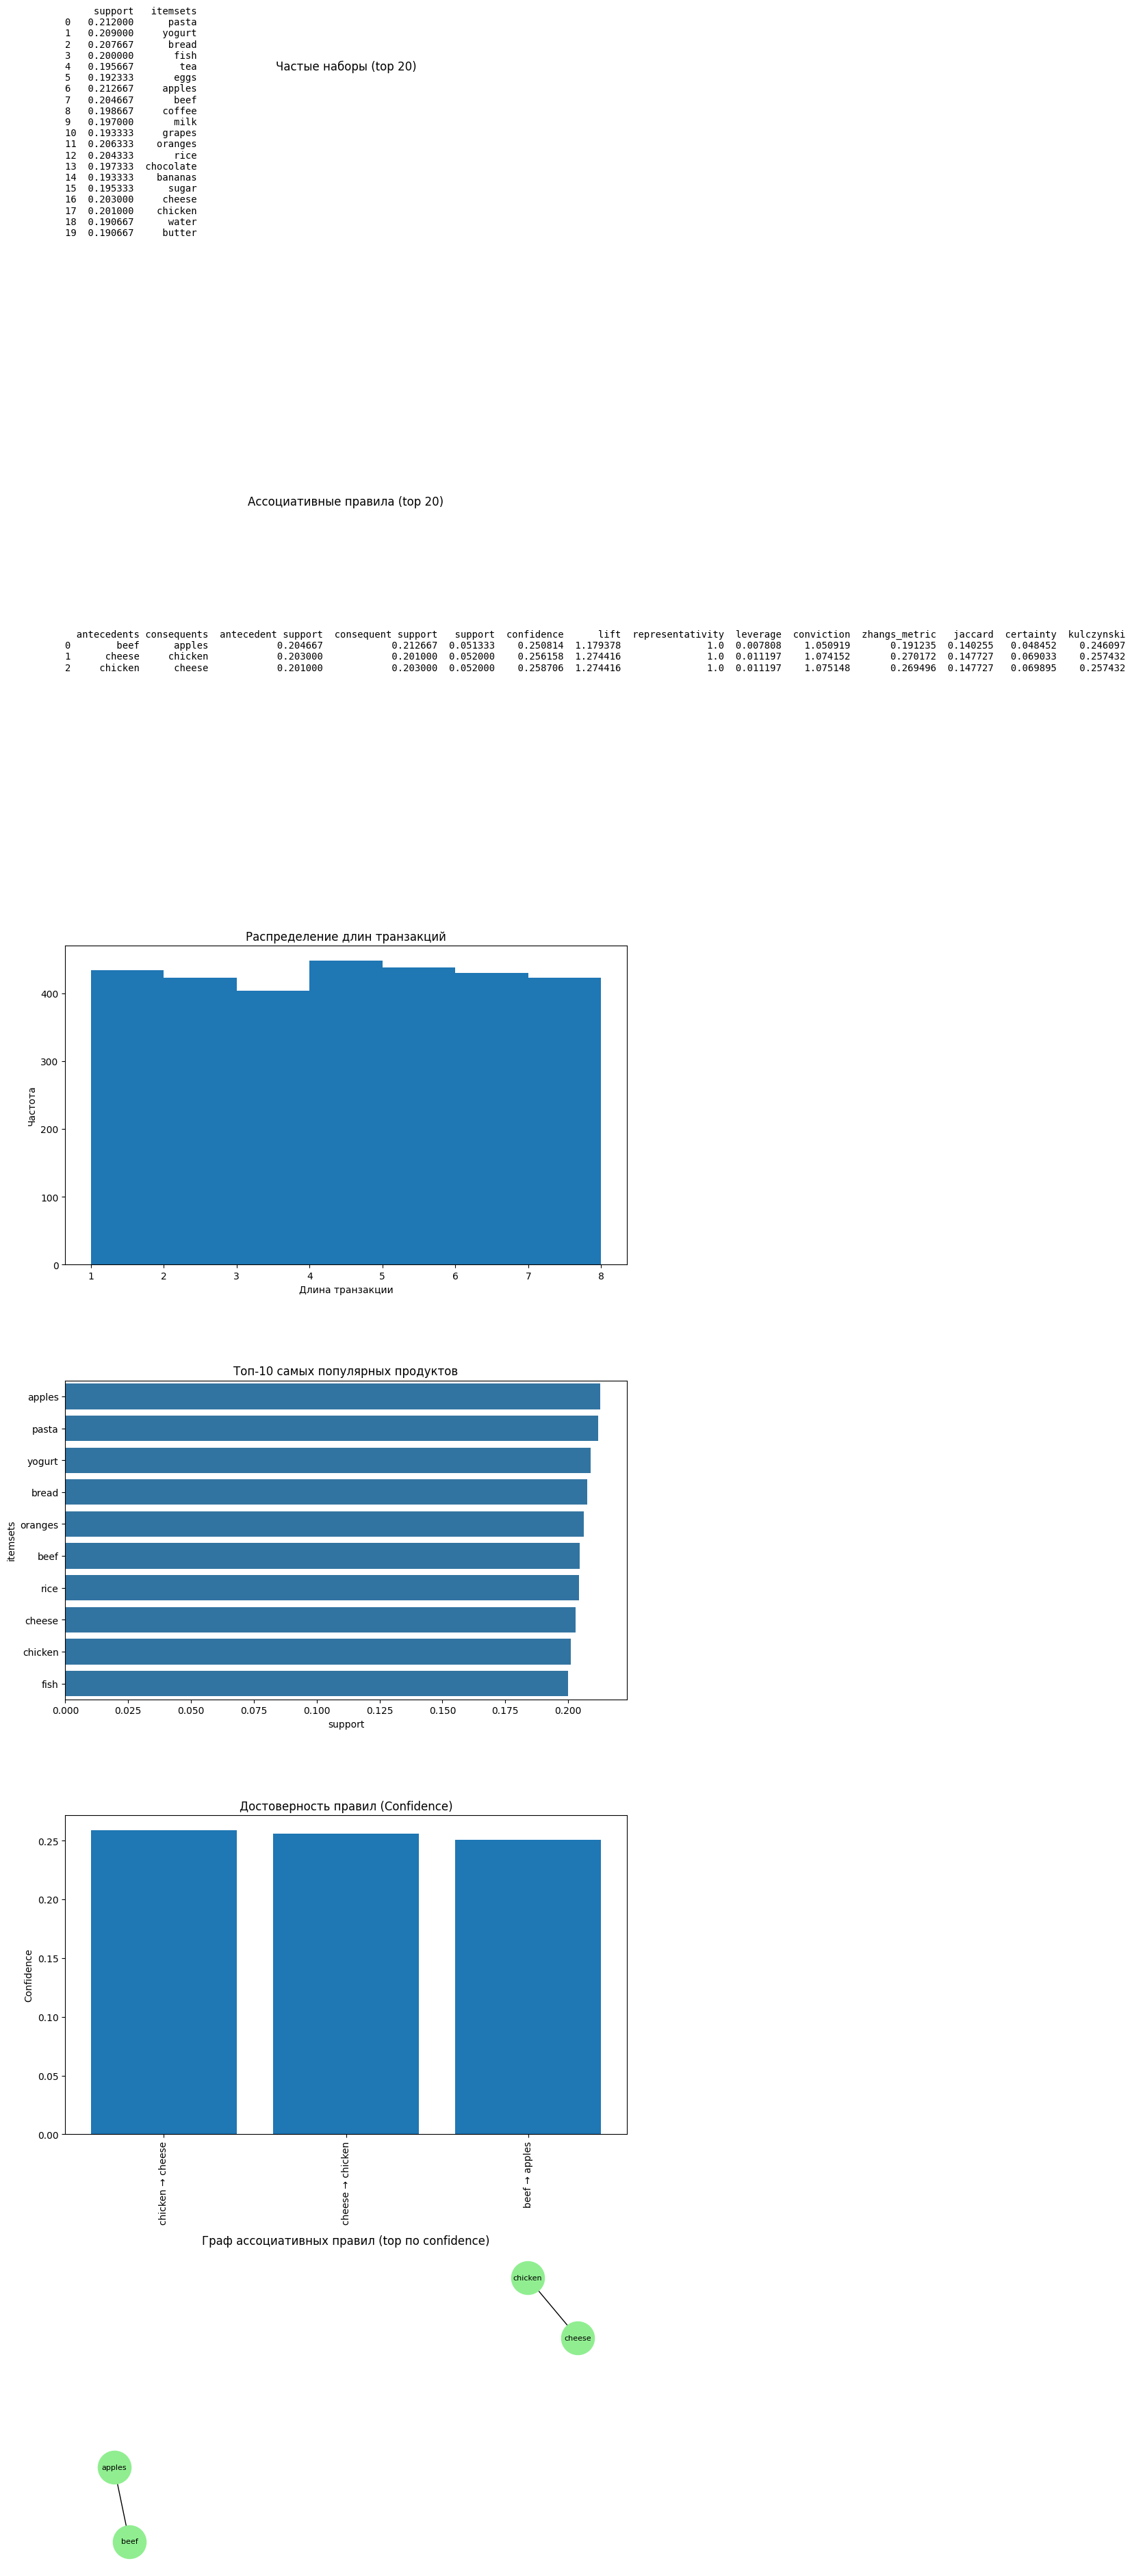

In [ ]:

fig = plt.figure(figsize=(14, 38))

# 1. Частые наборы (как текст)
plt.subplot(6, 1, 1)
plt.text(0, 0.5, df1.head(20).to_string(), fontsize=10, family="monospace")
plt.axis('off')
plt.title("Частые наборы (top 20)")

# 2. Правила (как текст)
plt.subplot(6, 1, 2)
plt.text(0, 0.5, rules.head(20).to_string(), fontsize=10, family="monospace")
plt.axis('off')
plt.title("Ассоциативные правила (top 20)")

# 3. Гистограмма длин транзакций
plt.subplot(6, 1, 3)
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths) + 2))
plt.title("Распределение длин транзакций")
plt.xlabel("Длина транзакции")
plt.ylabel("Частота")

# 4. Топ-10 продуктов
plt.subplot(6, 1, 4)
top10 = df1.sort_values(by="support", ascending=False).head(10)
sns.barplot(x="support", y="itemsets", data=top10)
plt.title("Топ-10 самых популярных продуктов")

# 5. Confidence (покажем топ-20 правил по confidence)
plt.subplot(6, 1, 5)
rules_sorted_conf = rules.sort_values(by='confidence', ascending=False).head(20)
rules_labels = [f"{a} → {b}" for a, b in zip(rules_sorted_conf['antecedents'], rules_sorted_conf['consequents'])]
plt.bar(rules_labels, rules_sorted_conf['confidence'])
plt.xticks(rotation=90)
plt.title("Достоверность правил (Confidence)")
plt.ylabel("Confidence")

# 6. Граф ассоциативных правил (упрощённый)
plt.subplot(6, 1, 6)
G = nx.Graph()
for _, r in rules_sorted_conf.iterrows():
    G.add_edge(r['antecedents'], r['consequents'], weight=r['confidence'])

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1200, font_size=8)
plt.title("Граф ассоциативных правил (top по confidence)")

plt.tight_layout()
plt.show()

## 9. Визуализация всех результатов (подробные пояснения)

Данный раздел выводит все результаты анализа в одном вертикальном окне из 6 частей.  
Каждый график помогает понять структуру транзакций, частоту товаров и зависимость между товарами.

### Граф 1: Частые наборы (текст)
- Отображает топ-20 частых наборов товаров, полученных с помощью алгоритма FPGrowth.
- Каждая строка показывает набор товаров и их поддержку (`support`) — долю транзакций, содержащих этот набор.
- Этот граф помогает быстро увидеть, какие комбинации товаров встречаются чаще всего.

### Граф 2: Ассоциативные правила (текст)
- Показывает топ-20 ассоциативных правил в формате «A → B», где A — исходный набор, B — следствие.
- Для каждого правила указаны параметры:
  - `support` — доля транзакций с этим правилом.
  - `confidence` — вероятность появления B при условии, что есть A.
  - `lift` — насколько вероятность появления B выше случайной.
- Позволяет быстро оценить, какие зависимости между товарами сильнее всего.

### Граф 3: Распределение длин транзакций (гистограмма)
- Показывает, сколько товаров в каждой транзакции встречается.
- По оси X — длина транзакции (количество товаров), по оси Y — количество транзакций.
- Помогает понять, насколько сложные и длинные наборы встречаются чаще всего.
- Например, если большинство транзакций содержит 3–5 товаров, это указывает на средний размер покупок.

### Граф 4: Топ-10 самых популярных наборов (барплот)
- Столбчатая диаграмма, показывающая наборы товаров с наибольшей поддержкой (`support`).
- Высота столбца отражает, как часто встречается этот набор среди всех транзакций.
- Этот граф позволяет визуально выявить самые популярные комбинации товаров.

### Граф 5: Достоверность правил (Confidence)
- Столбчатая диаграмма топ-20 правил, отсортированных по `confidence`.
- По оси Y — confidence, по оси X — правило в формате «A → B».
- Позволяет быстро увидеть, какие правила наиболее надёжные: чем выше confidence, тем сильнее связь между товарами.

### Граф 6: Граф ассоциативных правил (network graph)
- Визуализирует структуру ассоциативных правил как сеть:
  - Узлы — товары или наборы товаров.
  - Рёбра — правило «A → B», толщина/цвет может отражать `confidence`.
- Позволяет увидеть взаимосвязи между различными товарами в графическом виде.
- Особенно полезно для понимания сложных зависимостей, которые трудно увидеть в таблицах.

---

Таким образом, вся визуализация даёт комплексное понимание данных:
1. Тексты (графы 1 и 2) — детальные результаты алгоритма.  
2. Статистика (графы 3 и 4) — распределение и популярность товаров.  
3. Надёжность и связи (графы 5 и 6) — сила и структура правил.
